# PoreSpy permeability walkthrough

This notebook builds a seeded random geometry, runs the single-phase LBM solver, and then inspects permeability convergence together with the final density and velocity fields.


In [1]:
from pathlib import Path
import os
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import porespy as ps
import pyvista as pv
from matplotlib.colors import ListedColormap, TwoSlopeNorm
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

cwd = Path.cwd().resolve()
if (cwd / "examples" / "porespy_permeability").exists():
    repo_root = cwd
    example_dir = cwd / "examples" / "porespy_permeability"
elif cwd.name == "porespy_permeability":
    example_dir = cwd
    repo_root = cwd.parents[1]
else:
    raise FileNotFoundError(
        "Run this notebook from the repo root or from examples/porespy_permeability."
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

os.chdir(example_dir)
from latteasy.preprocessing.IO_tools import LattEasySimulation
example_dir


PosixPath('/Users/cedar/data/LattEasy/examples/porespy_permeability')

In [3]:
seed = 7
num_cores = 4
shape = (128, 128, 128)
porosity = 0.60
blobiness = 2
print(f"shape={shape}, porosity={porosity}, blobiness={blobiness}, seed={seed}, cores={num_cores}")

shape=(128, 128, 128), porosity=0.6, blobiness=2, seed=7, cores=4


## Geometry

The random seed is fixed so the example is repeatable. Change `seed` or `num_cores` in the configuration cell above if you want a different geometry or MPI process count.


In [ ]:
geometry = ps.generators.blobs(shape=list(shape), porosity=porosity, blobiness=blobiness, seed=seed).astype(bool)

display_geometry = geometry[::2, ::2, ::2]
grid = pv.ImageData(dimensions=display_geometry.shape)
grid.point_data["solid"] = (~display_geometry).astype(float).flatten(order="F")
surface = grid.contour(isosurfaces=[0.5], scalars="solid").triangulate()

points = surface.points * 2
faces = surface.faces.reshape(-1, 4)[:, 1:]
del surface

cmap = ListedColormap(["#51331d", "#9dd9f3"])
fig = plt.figure(figsize=(14, 10), constrained_layout=True)
layout = fig.add_gridspec(3, 2, width_ratios=[1.45, 1])

ax3d = fig.add_subplot(layout[:, 0], projection="3d")
ax3d.set_facecolor("#f5efe5")
mesh = Poly3DCollection(points[faces], facecolor="#c28f4a", edgecolor="none", alpha=0.15)
ax3d.add_collection3d(mesh)
ax3d.set_xlim(0, geometry.shape[0])
ax3d.set_ylim(0, geometry.shape[1])
ax3d.set_zlim(0, geometry.shape[2])
ax3d.set_box_aspect(geometry.shape)
ax3d.view_init(elev=24, azim=36)
ax3d.set_xticks([])
ax3d.set_yticks([])
ax3d.set_zticks([])
ax3d.grid(False)
ax3d.xaxis.pane.fill = False
ax3d.yaxis.pane.fill = False
ax3d.zaxis.pane.fill = False
ax3d.set_title("3D pore geometry")

slices = [
    ("Mid-x slice", geometry[geometry.shape[0] // 2, :, :].T),
    ("Mid-y slice", geometry[:, geometry.shape[1] // 2, :].T),
    ("Mid-z slice", geometry[:, :, geometry.shape[2] // 2].T),
]

for index, (title, plane) in enumerate(slices):
    ax = fig.add_subplot(layout[index, 1])
    ax.imshow(plane, origin="lower", cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f"Pore geometry, seed={seed}, porosity={geometry.mean():.3f}", fontsize=16, y=1.01)
print(f"Measured porosity: {geometry.mean():.4f}")
plt.show()
plt.close(fig)


Measured porosity: 0.6000


## Run the simulation

This launches the bundled permeability solver with the selected MPI process count.


In [4]:
simulation = LattEasySimulation(geometry, cpus=num_cores)
permeability = simulation.run_sim(mpi_procs=num_cores)

folder = Path(simulation.folder_path).resolve()
output_dir = folder / "output"
perm_log = folder / "perm.txt"

print(f"Permeability: {permeability:.5g} [l.u.^2]")
print(f"Simulation folder: {folder}")
print(f"perm.txt: {perm_log}")



LBM installation was found: /Users/jesantos/Desktop/LattEasy/latteasy/bin/permeability

Running: /opt/homebrew/bin/mpirun -n 4 /Users/jesantos/Desktop/LattEasy/latteasy/bin/permeability pore.xml
Permeability: 0.48415 [l.u.^2]
Simulation folder: /Users/jesantos/Desktop/LattEasy/examples/porespy_permeability/sims/pore_8
perm.txt: /Users/jesantos/Desktop/LattEasy/examples/porespy_permeability/sims/pore_8/perm.txt


## Permeability evolution

The solver writes intermediate permeability estimates to `perm.txt`. This plot extracts those values and shows how the run settles down in time.


In [9]:
iterations, permeabilities, relative_energy = [], [], []
current_iteration = None
current_energy = np.nan

for raw_line in perm_log.read_text().splitlines():
    line = raw_line.strip()

    match = re.search(r"Iteration\s+(\d+)", line)
    if match:
        current_iteration = int(match.group(1))
        current_energy = np.nan
        continue

    match = re.search(r"Relative difference of Energy:\s+([+\-0-9.eEinfaINFNAN]+)\s+%", line)
    if match and current_iteration is not None:
        current_energy = float(match.group(1))
        continue

    if "Absolute Permeability" in line:
        continue

    match = re.search(r"Permeability \[l\.u\.\^2\]\s*=\s*([+\-0-9.eE]+)", line)
    if match and current_iteration is not None:
        iterations.append(current_iteration)
        permeabilities.append(float(match.group(1)))
        relative_energy.append(current_energy)
        current_iteration = None

iterations = np.array(iterations)
permeabilities = np.array(permeabilities)
relative_energy = np.array(relative_energy)


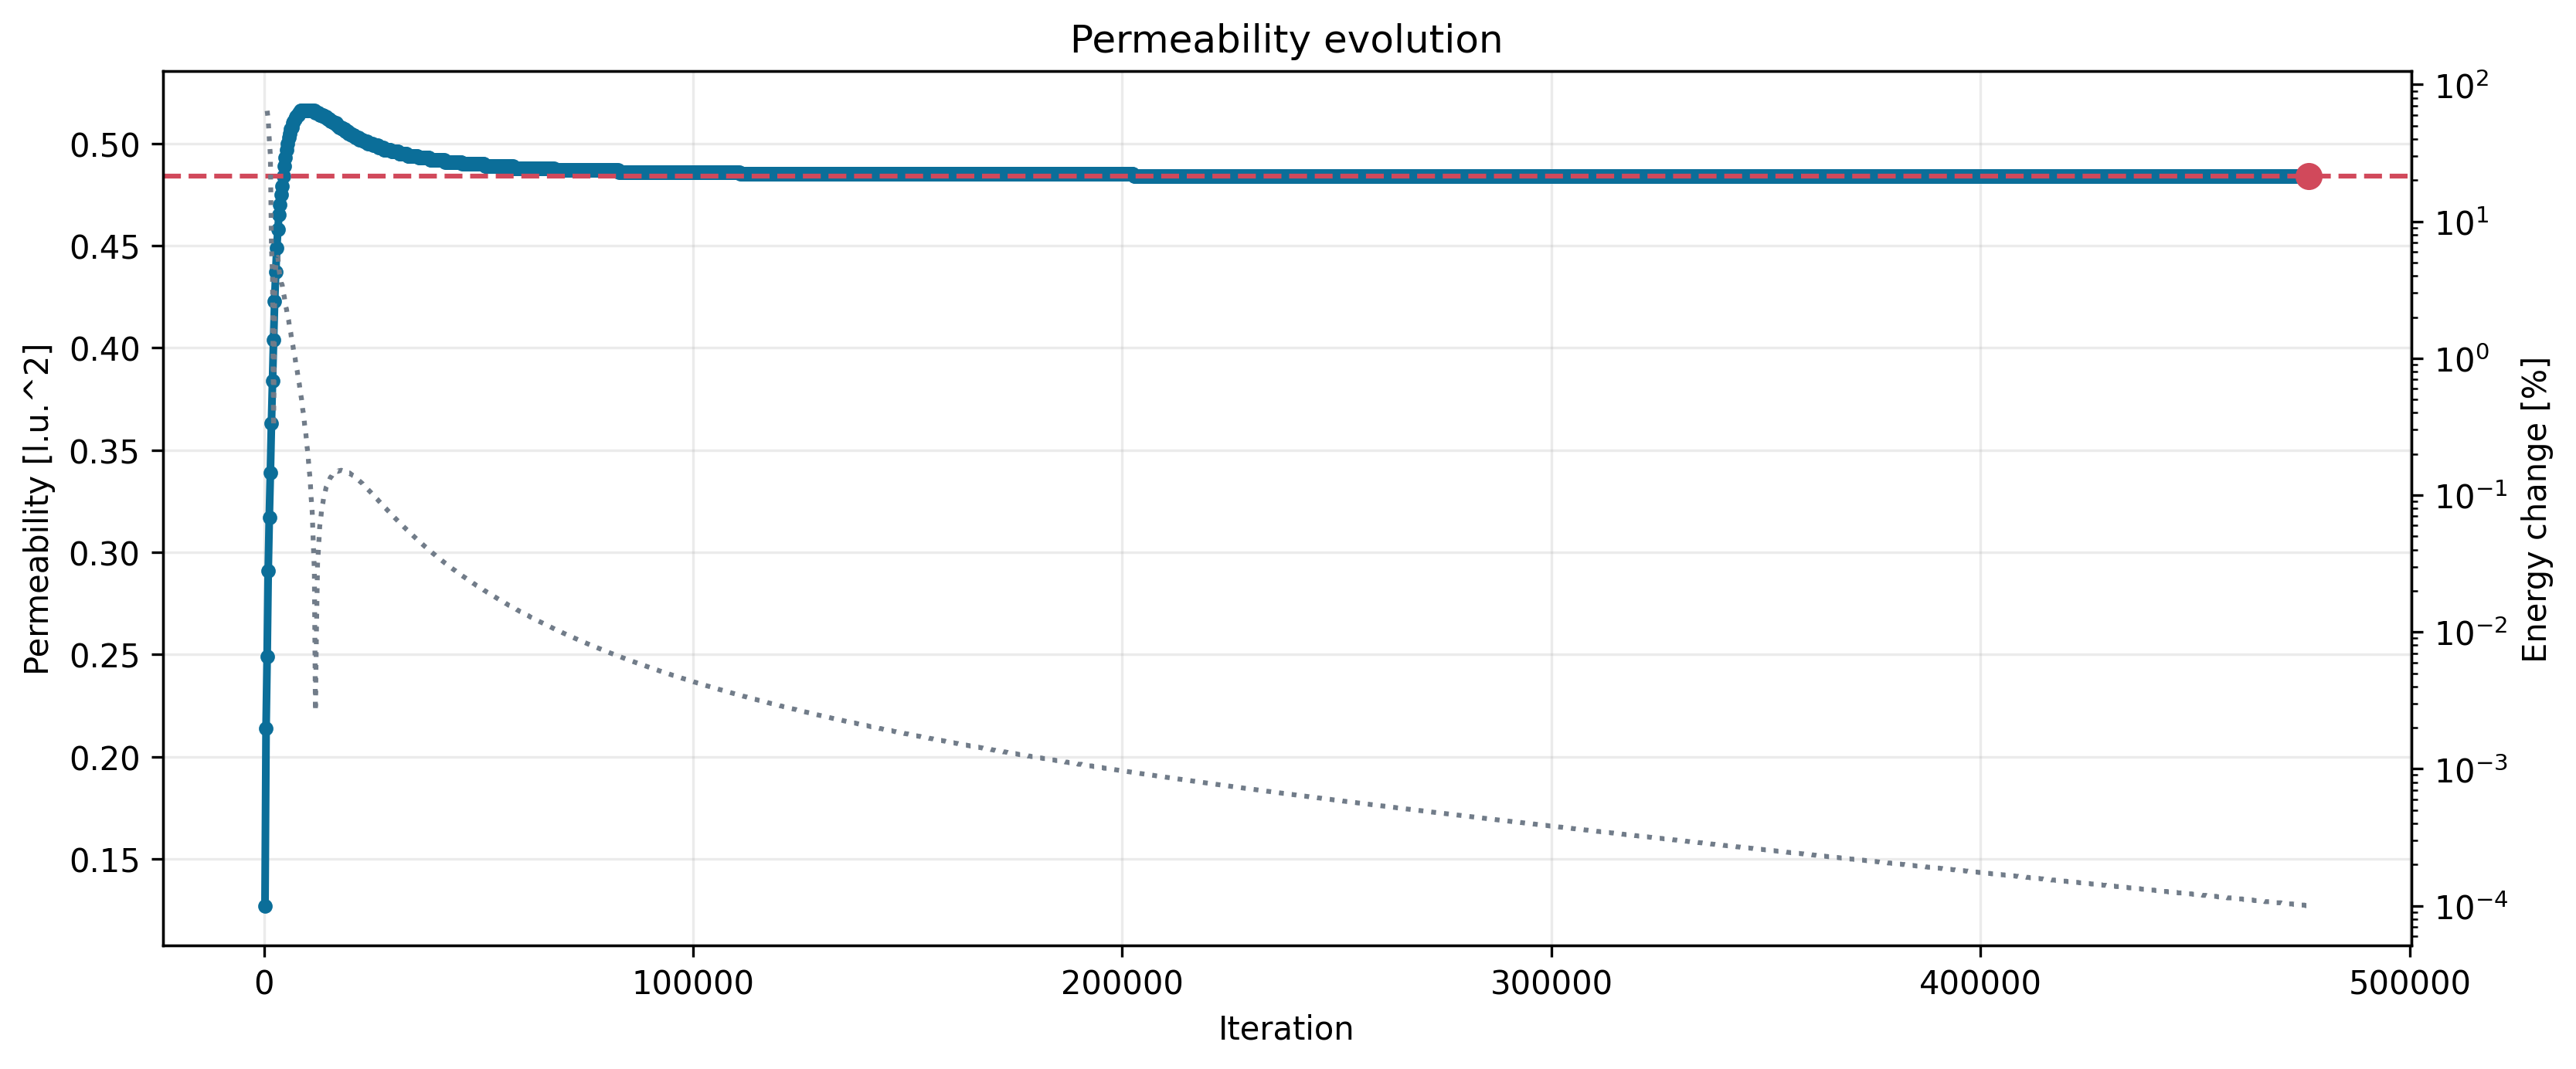

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True, dpi=300)
ax.plot(iterations, permeabilities, color="#0b6e99", marker="o", markersize=3.5, linewidth=2.4)
ax.axhline(permeability, color="#d1495b", linestyle="--", linewidth=1.5)
ax.scatter(iterations[-1], permeabilities[-1], color="#d1495b", s=55, zorder=3)
ax.set_xlabel("Iteration")
ax.set_ylabel("Permeability [l.u.^2]")
ax.set_title("Permeability evolution")
ax.grid(alpha=0.25)

energy_mask = np.isfinite(relative_energy) & (relative_energy > 0)
if energy_mask.any():
    twin = ax.twinx()
    twin.plot(iterations[energy_mask], relative_energy[energy_mask], color="#717c89", linestyle=":", linewidth=1.5)
    twin.set_yscale("log")
    twin.set_ylabel("Energy change [%]")

plt.show()
plt.close(fig)

## Final density and velocity fields

The field plots come from the solver's raw `*_rho.dat` and `*_vel.dat` outputs. The last panel shows a high-speed isosurface extracted from the full 3D velocity magnitude field.


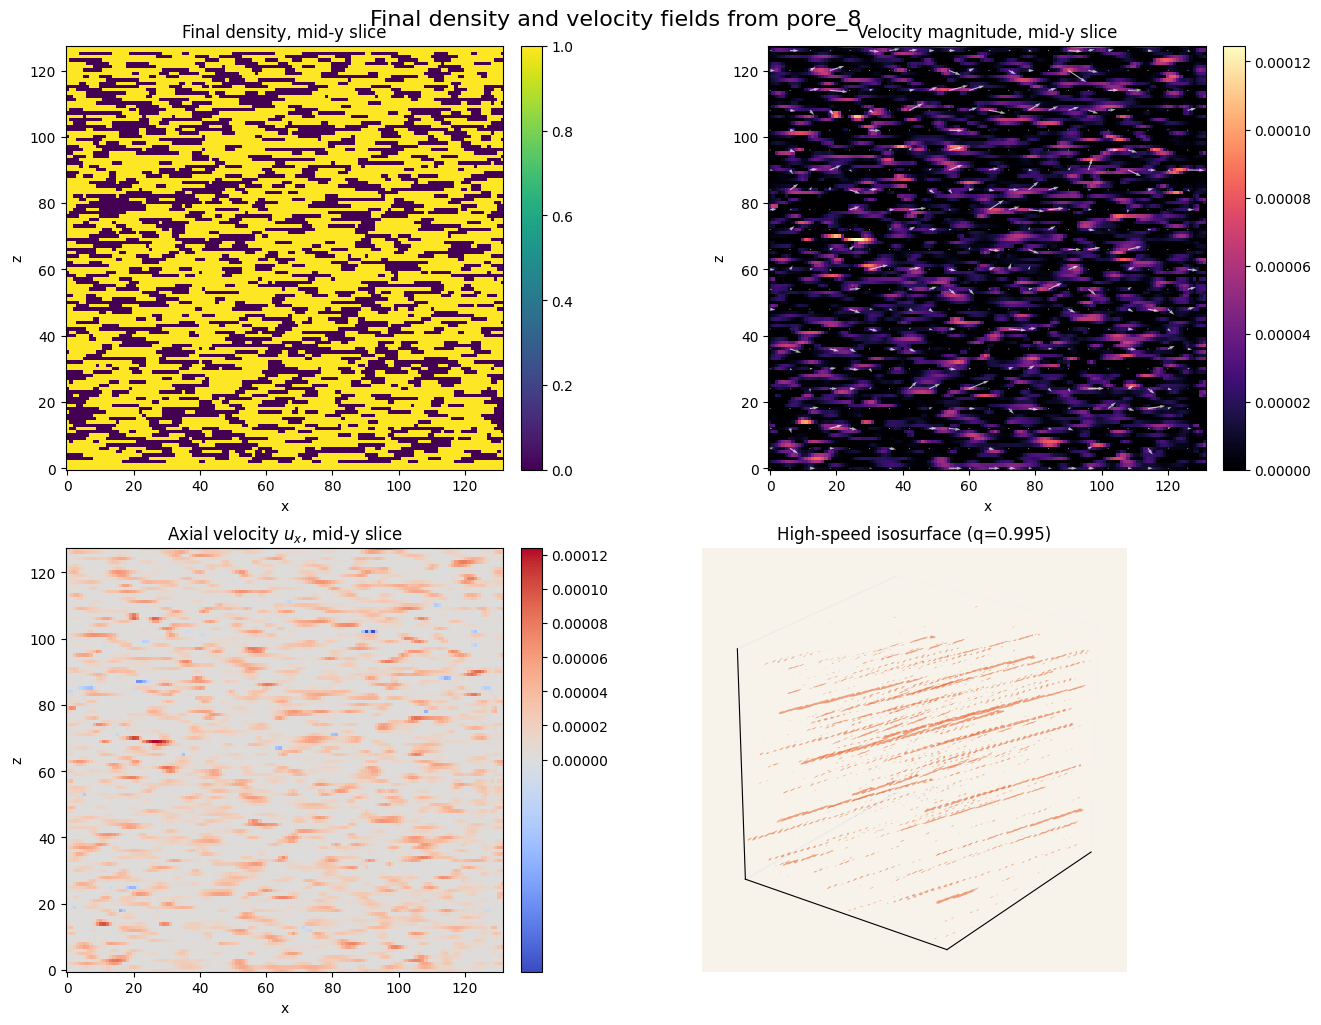

In [6]:
rho_path = sorted(output_dir.glob("*_rho.dat"))[-1]
vel_path = sorted(output_dir.glob("*_vel.dat"))[-1]

shape_match = re.search(r"_(\d+)_(\d+)_(\d+)_rho\.dat$", rho_path.name)
nx, ny, nz = [int(value) for value in shape_match.groups()]

density = np.loadtxt(rho_path).reshape((nx, ny, nz), order="F")

flat_velocity = np.loadtxt(vel_path).reshape(-1, 3)
velocity = np.stack([
    flat_velocity[:, 0].reshape((nx, ny, nz), order="F"),
    flat_velocity[:, 1].reshape((nx, ny, nz), order="F"),
    flat_velocity[:, 2].reshape((nx, ny, nz), order="F"),
], axis=-1)

speed = np.linalg.norm(velocity, axis=-1)
mid_y = ny // 2

density_slice = density[:, mid_y, :].T
speed_slice = speed[:, mid_y, :].T
ux_slice = velocity[:, mid_y, :, 0].T
uz_slice = velocity[:, mid_y, :, 2].T

speed_level = np.quantile(speed[speed > 0], 0.995)
grid = pv.ImageData(dimensions=speed.shape)
grid.point_data["speed"] = speed.flatten(order="F")
surface = grid.contour(isosurfaces=[float(speed_level)], scalars="speed").triangulate()
points = surface.points
faces = surface.faces.reshape(-1, 4)[:, 1:]
del surface

fig = plt.figure(figsize=(14, 10), constrained_layout=True)
layout = fig.add_gridspec(2, 2)

ax_density = fig.add_subplot(layout[0, 0])
density_image = ax_density.imshow(density_slice, origin="lower", cmap="viridis")
ax_density.set_title("Final density, mid-y slice")
ax_density.set_xlabel("x")
ax_density.set_ylabel("z")
fig.colorbar(density_image, ax=ax_density, fraction=0.046, pad=0.03)

ax_speed = fig.add_subplot(layout[0, 1])
speed_image = ax_speed.imshow(speed_slice, origin="lower", cmap="magma")

step = 6
z_coords = np.arange(0, speed_slice.shape[0], step)
x_coords = np.arange(0, speed_slice.shape[1], step)
x_grid, z_grid = np.meshgrid(x_coords, z_coords)
u_quiver = ux_slice[z_coords][:, x_coords]
w_quiver = uz_slice[z_coords][:, x_coords]
quiver_scale = np.max(np.abs(np.stack([u_quiver, w_quiver], axis=0)))

if quiver_scale > 0:
    ax_speed.quiver(
        x_grid,
        z_grid,
        u_quiver / quiver_scale,
        w_quiver / quiver_scale,
        color="white",
        alpha=0.7,
        scale=22,
        width=0.0025,
    )

ax_speed.set_title("Velocity magnitude, mid-y slice")
ax_speed.set_xlabel("x")
ax_speed.set_ylabel("z")
fig.colorbar(speed_image, ax=ax_speed, fraction=0.046, pad=0.03)

ax_ux = fig.add_subplot(layout[1, 0])
ux_image = ax_ux.imshow(
    ux_slice,
    origin="lower",
    cmap="coolwarm",
    norm=TwoSlopeNorm(vcenter=0.0, vmin=float(np.min(ux_slice)), vmax=float(np.max(ux_slice))),
)
ax_ux.set_title("Axial velocity $u_x$, mid-y slice")
ax_ux.set_xlabel("x")
ax_ux.set_ylabel("z")
fig.colorbar(ux_image, ax=ax_ux, fraction=0.046, pad=0.03)

ax_iso = fig.add_subplot(layout[1, 1], projection="3d")
ax_iso.set_facecolor("#f7f3ea")
iso_mesh = Poly3DCollection(points[faces], facecolor="#ef6c39", edgecolor="none", alpha=0.42)
ax_iso.add_collection3d(iso_mesh)
ax_iso.set_xlim(0, nx)
ax_iso.set_ylim(0, ny)
ax_iso.set_zlim(0, nz)
ax_iso.set_box_aspect((nx, ny, nz))
ax_iso.view_init(elev=24, azim=36)
ax_iso.set_xticks([])
ax_iso.set_yticks([])
ax_iso.set_zticks([])
ax_iso.grid(False)
ax_iso.xaxis.pane.fill = False
ax_iso.yaxis.pane.fill = False
ax_iso.zaxis.pane.fill = False
ax_iso.set_title("High-speed isosurface (q=0.995)")

fig.suptitle(f"Final density and velocity fields from {folder.name}", fontsize=16, y=1.01)
plt.show()
plt.close(fig)
